In [3]:
import cv2
import matplotlib.pyplot as plt


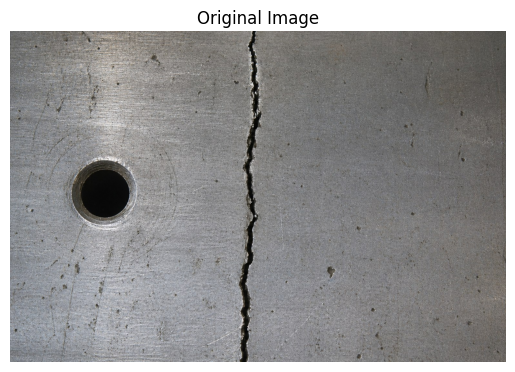

In [4]:

img = cv2.imread("/content/Unknown")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.title('Original Image')
plt.show()

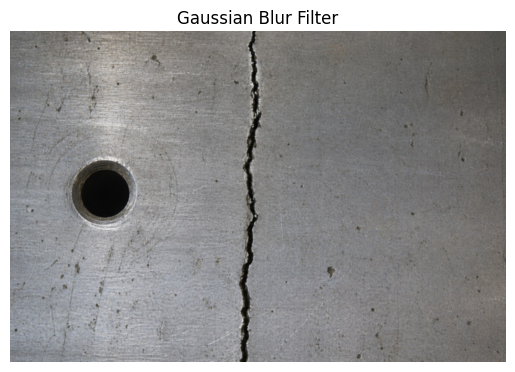

In [5]:

gaussian_blur = cv2.GaussianBlur(img_rgb, (5, 5), 0)

plt.imshow(gaussian_blur)
plt.axis('off')
plt.title('Gaussian Blur Filter')
plt.show()

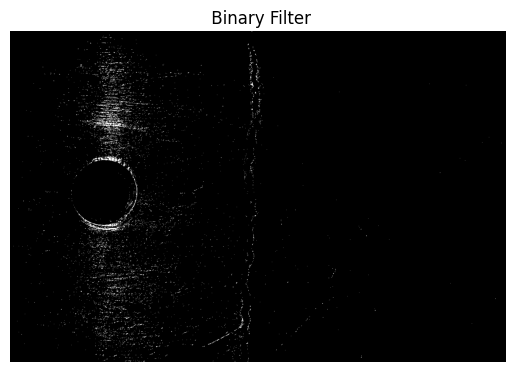

In [6]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


_, binary_img = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY)

plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.title(' Binary Filter')
plt.show()

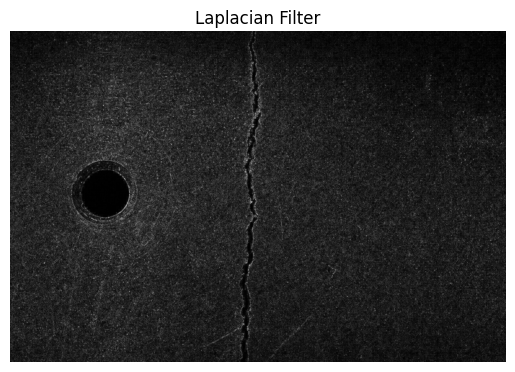

In [7]:

laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)

laplacian_display = cv2.convertScaleAbs(laplacian)

plt.imshow(laplacian_display, cmap='gray')
plt.axis('off')
plt.title('Laplacian Filter')
plt.show()

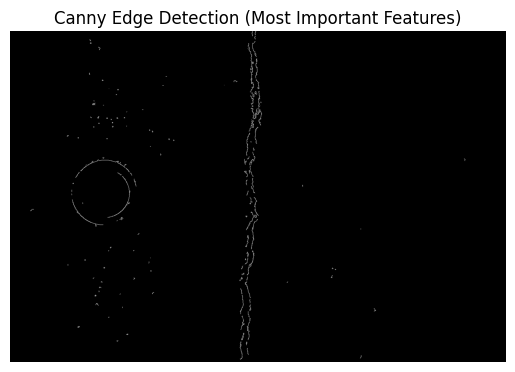

In [8]:

canny_edges = cv2.Canny(img_gray, 400, 700)

plt.imshow(canny_edges, cmap='gray')
plt.axis('off')
plt.title('Canny Edge Detection (Most Important Features)')
plt.show()

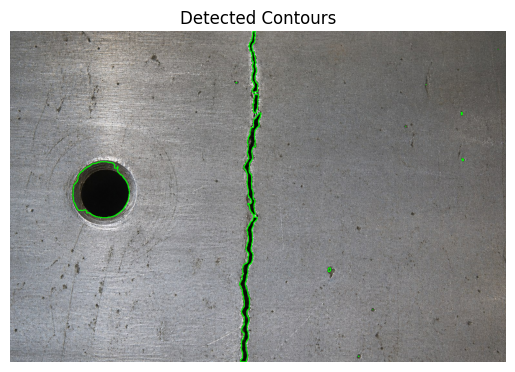

In [11]:
import numpy as np

strong_blurred_img = cv2.GaussianBlur(img_gray, (15, 15), 0)


_, thresholded_dark_spots = cv2.threshold(strong_blurred_img, 70, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((5,5), np.uint8)
closed_dark_spots = cv2.morphologyEx(thresholded_dark_spots, cv2.MORPH_CLOSE, kernel)


contours, _ = cv2.findContours(closed_dark_spots, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


contours = sorted(contours, key=cv2.contourArea, reverse=True)


contour_output_img = img_rgb.copy()


cv2.drawContours(contour_output_img, contours, -1, (0, 255, 0), 2)


plt.imshow(contour_output_img)
plt.axis('off')
plt.title('Detected Contours')
plt.show()